# Модель связи валютных курсов и цены на нефть

**Тема:** сравнительный анализ Норвегии и Швеции

**Идея проекта:** проверить, сильнее ли норвежская крона связана с ценой нефти Brent, чем шведская крона, и показать, как нефтяной фактор влияет на валютный риск.

В проекте используются:
- цена нефти Brent
- курс USD/NOK
- курс USD/SEK
- лог-доходности
- корреляции
- OLS-регрессии
- rolling beta
- VaR и Expected Shortfall
- сценарный анализ нефтяного шока


## 1. Библиотеки и настройки


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

data_dir = Path("data")
output_dir = Path("outputs")

data_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)


## 2. Параметры проекта


In [2]:
start_date = "2000-01-01"
end_date = None

fred_series = {
  "brent": "DCOILBRENTEU",
  "usd_nok": "DEXNOUS",
  "usd_sek": "DEXSDUS"
}

rolling_window = 252
hac_lags = 5
var_levels = [0.95, 0.99]


## 3. Загрузка данных

Все ряды берутся из FRED. Это удобно для воспроизводимости: один источник, одинаковый формат, дневная частота.


In [3]:
def load_fred_series(series_id):
  url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
  data = pd.read_csv(url, na_values=[".", ""])

  data.columns = [str(col).strip() for col in data.columns]

  if len(data.columns) < 2:
    raise ValueError(
      f"FRED вернул некорректную таблицу для {series_id}. "
      f"Полученные столбцы: {list(data.columns)}"
    )

  date_col = data.columns[0]
  value_col = data.columns[1]

  data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
  data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

  data = data.dropna(subset=[date_col])
  data = data.set_index(date_col)

  return data[value_col].rename(series_id)


raw = pd.DataFrame()

for name, series_id in fred_series.items():
  raw[name] = load_fred_series(series_id)

raw = raw.sort_index()
raw = raw.loc[raw.index >= pd.to_datetime(start_date)]

if end_date is not None:
  raw = raw.loc[raw.index <= pd.to_datetime(end_date)]

raw = raw.dropna()

raw.to_csv(data_dir / "raw_fred_data.csv")

raw.head()

,brent,usd_nok,usd_sek
observation_date,,,
2000-01-04,23.95,7.934,8.3600
2000-01-05,23.72,7.935,8.3530
2000-01-06,23.55,7.940,8.3675
2000-01-07,23.35,7.966,8.4150
2000-01-10,22.77,8.024,8.4490


## 4. Проверка данных


In [4]:
data_info = pd.DataFrame({
  "first_date": raw.apply(lambda x: x.dropna().index.min()),
  "last_date": raw.apply(lambda x: x.dropna().index.max()),
  "observations": raw.count(),
  "missing": raw.isna().sum()
})

data_info


,first_date,last_date,observations,missing
brent,2000-01-04,2026-05-11,6523,0
usd_nok,2000-01-04,2026-05-11,6523,0
usd_sek,2000-01-04,2026-05-11,6523,0


In [5]:
raw.describe().T


,count,mean,std,min,25%,50%,75%,max
brent,6523.0,67.090630,28.403411,9.1200,45.08000,66.2300,85.06500,143.9500
usd_nok,6523.0,7.742383,1.656231,4.9467,6.17275,7.8285,8.91555,11.6842
usd_sek,6523.0,8.347565,1.382998,5.8346,7.08785,8.3683,9.39780,11.3450


## 5. Графики уровней

Важно помнить: USD/NOK и USD/SEK показывают, сколько крон нужно за 1 доллар. Рост ряда означает ослабление местной валюты к доллару.


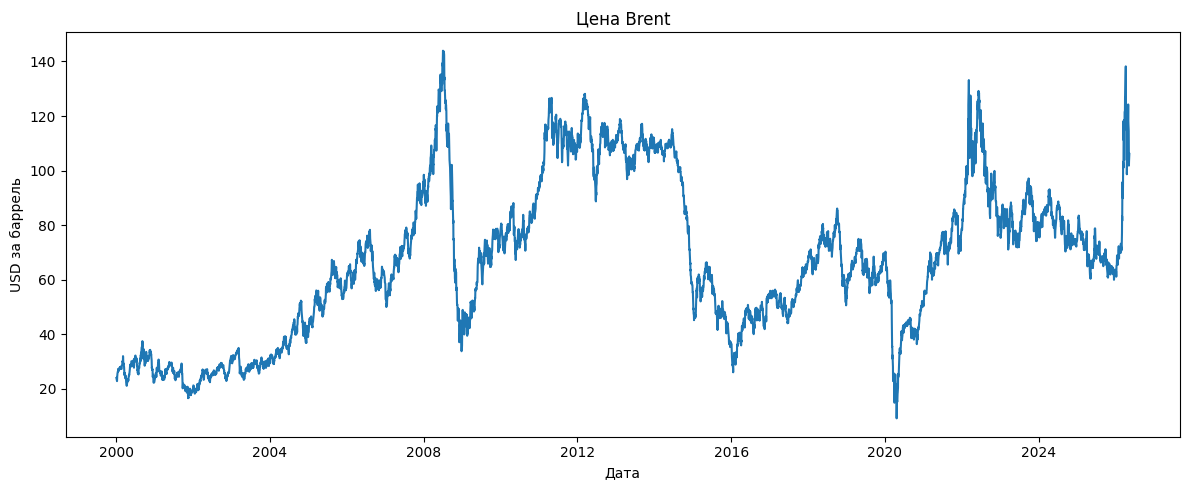

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(raw.index, raw["brent"])
plt.title("Цена Brent")
plt.xlabel("Дата")
plt.ylabel("USD за баррель")
plt.tight_layout()
plt.savefig(output_dir / "brent_level.png", dpi=200)
plt.show()


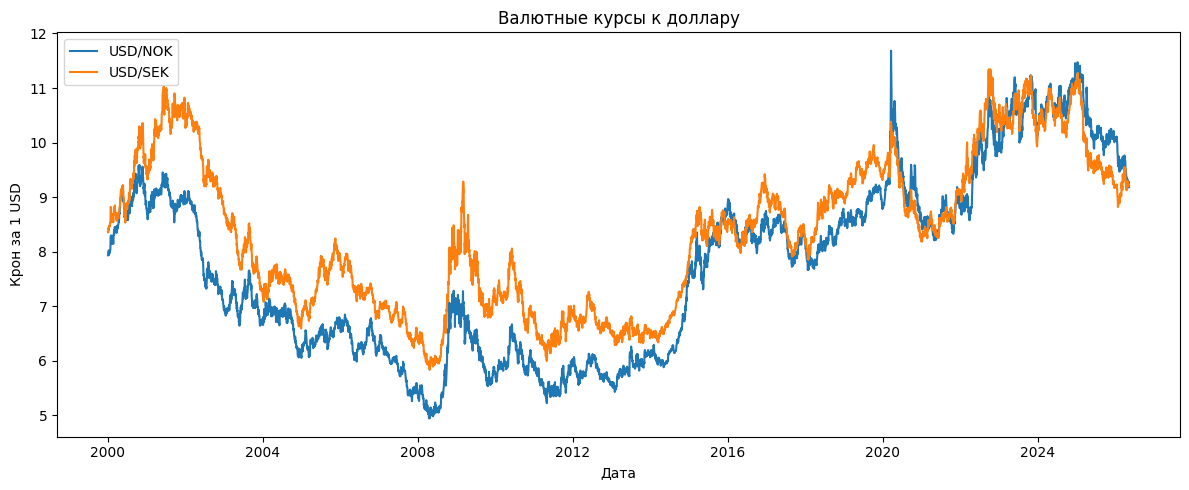

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(raw.index, raw["usd_nok"], label="USD/NOK")
plt.plot(raw.index, raw["usd_sek"], label="USD/SEK")
plt.title("Валютные курсы к доллару")
plt.xlabel("Дата")
plt.ylabel("Крон за 1 USD")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "fx_levels.png", dpi=200)
plt.show()


## 6. Переход к лог-доходностям

Для эконометрического анализа используются лог-доходности.

Для валют дополнительно строится показатель силы валюты:

$$r^{strength}_{NOK,t}=-\Delta \ln(USD/NOK)_t$$

$$r^{strength}_{SEK,t}=-\Delta \ln(USD/SEK)_t$$

Если показатель положительный, местная валюта укрепляется относительно доллара.


In [8]:
returns = np.log(raw).diff().dropna()

returns = returns.rename(columns={
  "brent": "oil_ret",
  "usd_nok": "usd_nok_ret",
  "usd_sek": "usd_sek_ret"
})

returns["nok_strength"] = -returns["usd_nok_ret"]
returns["sek_strength"] = -returns["usd_sek_ret"]

returns["nok_loss"] = returns["usd_nok_ret"]
returns["sek_loss"] = returns["usd_sek_ret"]

returns.to_csv(data_dir / "returns.csv")

returns.head()


,oil_ret,usd_nok_ret,usd_sek_ret,nok_strength,sek_strength,nok_loss,sek_loss
observation_date,,,,,,,
2000-01-05,-0.009650,0.000126,-0.000838,-0.000126,0.000838,0.000126,-0.000838
2000-01-06,-0.007193,0.000630,0.001734,-0.000630,-0.001734,0.000630,0.001734
2000-01-07,-0.008529,0.003269,0.005661,-0.003269,-0.005661,0.003269,0.005661
2000-01-10,-0.025153,0.007255,0.004032,-0.007255,-0.004032,0.007255,0.004032
2000-01-11,0.049689,-0.006878,-0.006174,0.006878,0.006174,-0.006878,-0.006174


## Эконометрический блок

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_coint_rank, VECM

### Лог-уровни

In [10]:
log_levels = np.log(raw[["brent", "usd_nok", "usd_sek"]]).dropna()

log_levels = log_levels.rename(columns={
  "brent": "log_brent",
  "usd_nok": "log_usd_nok",
  "usd_sek": "log_usd_sek"
})

log_levels.head()

,log_brent,log_usd_nok,log_usd_sek
observation_date,,,
2000-01-04,3.175968,2.071157,2.123458
2000-01-05,3.166319,2.071283,2.122621
2000-01-06,3.159126,2.071913,2.124355
2000-01-07,3.150597,2.075182,2.130016
2000-01-10,3.125444,2.082437,2.134048


### ADF и KPSS

In [11]:
def stationarity_tests(series, name):
  values = series.dropna()

  adf_result = adfuller(values, autolag="AIC")
  kpss_result = kpss(values, regression="c", nlags="auto")

  return {
    "series": name,
    "adf_stat": adf_result[0],
    "adf_p_value": adf_result[1],
    "kpss_stat": kpss_result[0],
    "kpss_p_value": kpss_result[1],
    "observations": len(values)
  }


stationarity_rows = []

for col in log_levels.columns:
  stationarity_rows.append(stationarity_tests(log_levels[col], col))

for col in ["oil_ret", "usd_nok_ret", "usd_sek_ret", "nok_strength", "sek_strength"]:
  stationarity_rows.append(stationarity_tests(returns[col], col))

stationarity_table = pd.DataFrame(stationarity_rows)

stationarity_table.to_csv(output_dir / "stationarity_tests.csv", index=False)

stationarity_table

,series,adf_stat,adf_p_value,kpss_stat,kpss_p_value,observations
0,log_brent,-2.483864,1.194498e-01,4.020140,0.01,6523
1,log_usd_nok,-1.325527,6.174144e-01,5.929041,0.01,6523
2,log_usd_sek,-1.579959,4.936526e-01,3.971123,0.01,6523
3,oil_ret,-13.849630,7.044150e-26,0.052988,0.10,6522
4,usd_nok_ret,-58.555506,0.000000e+00,0.142742,0.10,6522
5,usd_sek_ret,-26.606315,0.000000e+00,0.085912,0.10,6522
6,nok_strength,-58.555506,0.000000e+00,0.142742,0.10,6522
7,sek_strength,-26.606315,0.000000e+00,0.085912,0.10,6522


### Интерпретация стационарности

In [12]:
stationarity_interpretation = []

for _, row in stationarity_table.iterrows():
  if row["adf_p_value"] < 0.05 and row["kpss_p_value"] > 0.05:
    result = "ряд можно считать стационарным"
  elif row["adf_p_value"] >= 0.05 and row["kpss_p_value"] <= 0.05:
    result = "ряд, вероятно, нестационарен"
  else:
    result = "результат неоднозначный"

  stationarity_interpretation.append({
    "series": row["series"],
    "interpretation": result
  })

stationarity_interpretation = pd.DataFrame(stationarity_interpretation)

stationarity_interpretation.to_csv(output_dir / "stationarity_interpretation.csv", index=False)

stationarity_interpretation

,series,interpretation
0,log_brent,"ряд, вероятно, нестационарен"
1,log_usd_nok,"ряд, вероятно, нестационарен"
2,log_usd_sek,"ряд, вероятно, нестационарен"
3,oil_ret,ряд можно считать стационарным
4,usd_nok_ret,ряд можно считать стационарным
5,usd_sek_ret,ряд можно считать стационарным
6,nok_strength,ряд можно считать стационарным
7,sek_strength,ряд можно считать стационарным


### Выбор лагов для VAR на доходностях

In [13]:
var_data = returns[["oil_ret", "nok_strength", "sek_strength"]].dropna()

var_model = VAR(var_data)
lag_selection = var_model.select_order(maxlags=20)

lag_selection.summary()

,AIC,BIC,FPE,HQIC
0,-27.90,-27.89*,7.667e-13,-27.90
1,-27.90,-27.89,7.637e-13,-27.90*
2,-27.90,-27.88,7.629e-13,-27.89
3,-27.90,-27.87,7.633e-13,-27.89
4,-27.90,-27.86,7.629e-13,-27.89
5,-27.90,-27.85,7.636e-13,-27.88
6,-27.90,-27.84,7.644e-13,-27.88
7,-27.90,-27.83,7.646e-13,-27.88
8,-27.90,-27.82,7.641e-13,-27.87
9,-27.90,-27.81,7.637e-13,-27.87


### Автоматически взять лаг по AIC

In [14]:
selected_lag_aic = lag_selection.selected_orders["aic"]

if selected_lag_aic is None or selected_lag_aic < 1:
  selected_lag_aic = 1

selected_lag_aic

np.int64(20)

### VAR на доходностях

In [15]:
var_fit = var_model.fit(selected_lag_aic)

var_summary_text = str(var_fit.summary())

with open(output_dir / "var_model_summary.txt", "w", encoding="utf-8") as file:
  file.write(var_summary_text)

print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 20, May, 2026
Time:                     11:02:09
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -27.7162
Nobs:                     6502.00    HQIC:                  -27.8410
Log likelihood:           63230.9    FPE:                7.58820e-13
AIC:                     -27.9070    Det(Omega_mle):     7.37857e-13
--------------------------------------------------------------------
Results for equation oil_ret
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.000218         0.000328            0.664           0.506
L1.oil_ret              -0.016504         0.012975           -1.272           0.203
L1.nok_strength          0.148672         0.07

### Impulse Response Function

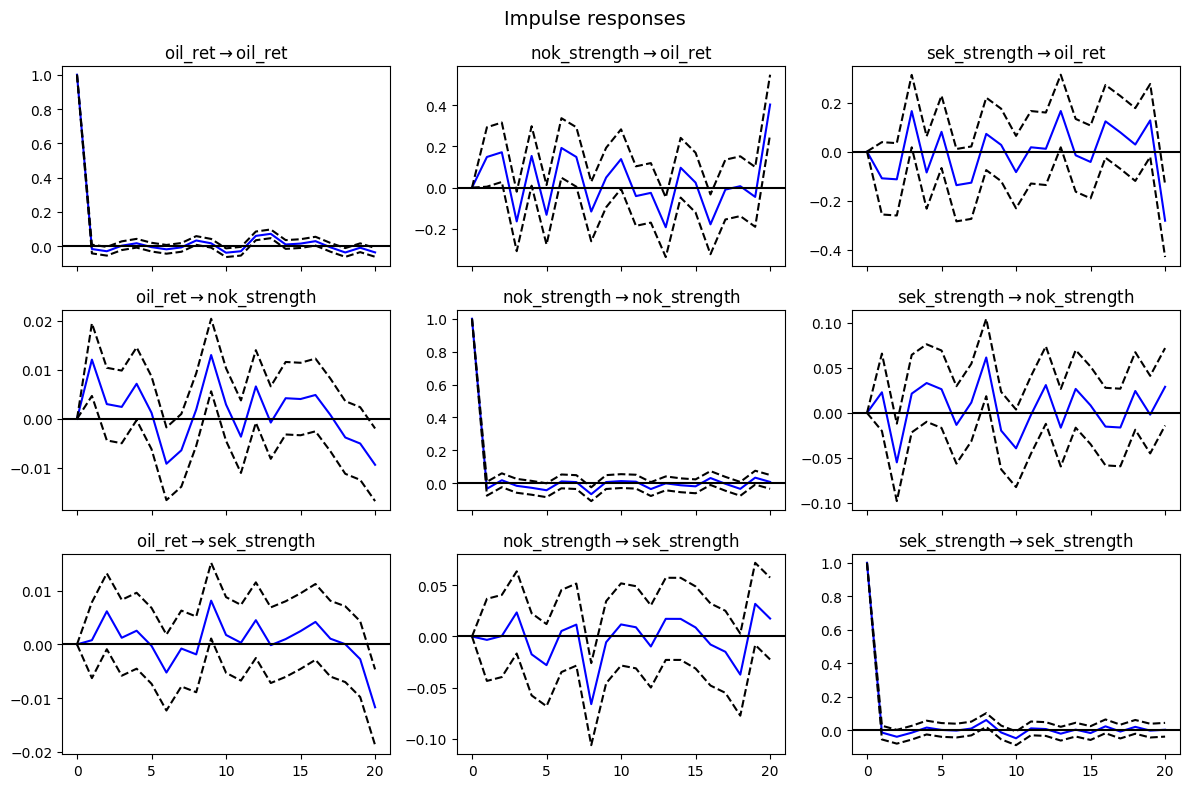

In [16]:
irf = var_fit.irf(20)

fig = irf.plot(orth=False)
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig(output_dir / "var_irf.png", dpi=200)
plt.show()

### Проверка коинтеграции Йохансена

In [17]:
johansen_data = log_levels[["log_brent", "log_usd_nok", "log_usd_sek"]].dropna()

johansen_lag_order = max(selected_lag_aic - 1, 1)

rank_test = select_coint_rank(
  johansen_data,
  det_order=0,
  k_ar_diff=johansen_lag_order,
  method="trace",
  signif=0.05
)

print(rank_test.summary())

Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   3          26.17          29.80
-------------------------------------


### Таблица теста Йохансена

In [18]:
johansen_result = coint_johansen(
  johansen_data,
  det_order=0,
  k_ar_diff=johansen_lag_order
)

johansen_table = pd.DataFrame({
  "rank_null": list(range(len(johansen_result.lr1))),
  "trace_stat": johansen_result.lr1,
  "crit_90": johansen_result.cvt[:, 0],
  "crit_95": johansen_result.cvt[:, 1],
  "crit_99": johansen_result.cvt[:, 2]
})

johansen_table["reject_95"] = johansen_table["trace_stat"] > johansen_table["crit_95"]

johansen_table.to_csv(output_dir / "johansen_cointegration_test.csv", index=False)

johansen_table

,rank_null,trace_stat,crit_90,crit_95,crit_99,reject_95
0,0,26.172814,27.0669,29.7961,35.4628,False
1,1,9.243970,13.4294,15.4943,19.9349,False
2,2,1.136471,2.7055,3.8415,6.6349,False


### VECM, если коинтеграция есть

In [19]:
coint_rank = rank_test.rank

if coint_rank > 0:
  vecm_model = VECM(
    johansen_data,
    k_ar_diff=johansen_lag_order,
    coint_rank=coint_rank,
    deterministic="co"
  )

  vecm_fit = vecm_model.fit()
  vecm_summary_text = str(vecm_fit.summary())

  with open(output_dir / "vecm_model_summary.txt", "w", encoding="utf-8") as file:
    file.write(vecm_summary_text)

  print(vecm_fit.summary())
else:
  print("Коинтеграция не обнаружена на 5% уровне, поэтому VECM не строится. Основная расширенная модель - VAR на доходностях.")

Коинтеграция не обнаружена на 5% уровне, поэтому VECM не строится. Основная расширенная модель - VAR на доходностях.


### Загрузка CPI/PPI

In [20]:
inflation_series = {
  "cpi_usa": "CPIAUCSL",
  "ppi_usa": "PPIACO",
  "cpi_norway": "NORCPALTT01IXNBM",
  "cpi_sweden": "SWECPALTT01IXNBM"
}

inflation = pd.DataFrame()

for name, series_id in inflation_series.items():
  inflation[name] = load_fred_series(series_id)

inflation = inflation.sort_index()
inflation = inflation.resample("D").ffill()

inflation.head()

,cpi_usa,ppi_usa,cpi_norway,cpi_sweden
observation_date,,,,
1947-01-01,21.48,24.5,NaN,NaN
1947-01-02,21.48,24.5,NaN,NaN
1947-01-03,21.48,24.5,NaN,NaN
1947-01-04,21.48,24.5,NaN,NaN
1947-01-05,21.48,24.5,NaN,NaN


### Объединение дневных данных с CPI/PPI

In [21]:
real_data = raw.join(inflation, how="inner").dropna()

real_data = real_data.loc[real_data.index >= raw.index.min()]
real_data = real_data.loc[real_data.index <= raw.index.max()]

real_data.head()

,brent,usd_nok,usd_sek,cpi_usa,ppi_usa,cpi_norway,cpi_sweden
observation_date,,,,,,,
2000-01-04,23.95,7.934,8.3600,169.3,128.3,74.5,257.82
2000-01-05,23.72,7.935,8.3530,169.3,128.3,74.5,257.82
2000-01-06,23.55,7.940,8.3675,169.3,128.3,74.5,257.82
2000-01-07,23.35,7.966,8.4150,169.3,128.3,74.5,257.82
2000-01-10,22.77,8.024,8.4490,169.3,128.3,74.5,257.82


### Реальная цена нефти и реальные валютные курсы

In [22]:
real_data["real_brent_cpi"] = real_data["brent"] * real_data["cpi_usa"].iloc[0] / real_data["cpi_usa"]
real_data["real_brent_ppi"] = real_data["brent"] * real_data["ppi_usa"].iloc[0] / real_data["ppi_usa"]

real_data["real_usd_nok"] = np.log(real_data["usd_nok"]) + np.log(real_data["cpi_usa"]) - np.log(real_data["cpi_norway"])
real_data["real_usd_sek"] = np.log(real_data["usd_sek"]) + np.log(real_data["cpi_usa"]) - np.log(real_data["cpi_sweden"])

real_returns = pd.DataFrame(index=real_data.index)

real_returns["real_oil_ret_cpi"] = np.log(real_data["real_brent_cpi"]).diff()
real_returns["real_oil_ret_ppi"] = np.log(real_data["real_brent_ppi"]).diff()
real_returns["real_nok_strength"] = -real_data["real_usd_nok"].diff()
real_returns["real_sek_strength"] = -real_data["real_usd_sek"].diff()

real_returns = real_returns.dropna()

real_returns.to_csv(output_dir / "real_returns.csv")

real_returns.head()

,real_oil_ret_cpi,real_oil_ret_ppi,real_nok_strength,real_sek_strength
observation_date,,,,
2000-01-05,-0.009650,-0.009650,-0.000126,0.000838
2000-01-06,-0.007193,-0.007193,-0.000630,-0.001734
2000-01-07,-0.008529,-0.008529,-0.003269,-0.005661
2000-01-10,-0.025153,-0.025153,-0.007255,-0.004032
2000-01-11,0.049689,0.049689,0.006878,0.006174


In [23]:
import statsmodels.api as sm

hac_lags = 5

def fit_ols(data, y_col, x_cols, model_name):
  model_data = data[[y_col] + x_cols].dropna()
  y = model_data[y_col]
  x = sm.add_constant(model_data[x_cols])

  fit = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

  table = pd.DataFrame({
    "model": model_name,
    "variable": fit.params.index,
    "coef": fit.params.values,
    "std_err": fit.bse.values,
    "t_stat": fit.tvalues.values,
    "p_value": fit.pvalues.values,
    "r2": fit.rsquared,
    "nobs": int(fit.nobs)
  })

  return fit, table

### Регрессии на дефлированных рядах

In [24]:
real_nok_fit_cpi, real_nok_table_cpi = fit_ols(
  real_returns,
  "real_nok_strength",
  ["real_oil_ret_cpi"],
  "Real NOK CPI"
)

real_sek_fit_cpi, real_sek_table_cpi = fit_ols(
  real_returns,
  "real_sek_strength",
  ["real_oil_ret_cpi"],
  "Real SEK CPI"
)

real_nok_fit_ppi, real_nok_table_ppi = fit_ols(
  real_returns,
  "real_nok_strength",
  ["real_oil_ret_ppi"],
  "Real NOK PPI"
)

real_sek_fit_ppi, real_sek_table_ppi = fit_ols(
  real_returns,
  "real_sek_strength",
  ["real_oil_ret_ppi"],
  "Real SEK PPI"
)

real_models = pd.concat([
  real_nok_table_cpi,
  real_sek_table_cpi,
  real_nok_table_ppi,
  real_sek_table_ppi
], ignore_index=True)

real_models.to_csv(output_dir / "real_regression_results.csv", index=False)

real_models

,model,variable,coef,std_err,t_stat,p_value,r2,nobs
0,Real NOK CPI,const,-0.000065,0.000094,-0.690033,4.901735e-01,0.076108,5925
1,Real NOK CPI,real_oil_ret_cpi,0.081156,0.011751,6.906255,4.976135e-12,0.076108,5925
2,Real SEK CPI,const,-0.000066,0.000092,-0.715312,4.744160e-01,0.032886,5925
3,Real SEK CPI,real_oil_ret_cpi,0.050838,0.008607,5.906754,3.489142e-09,0.032886,5925
4,Real NOK PPI,const,-0.000064,0.000094,-0.678599,4.973921e-01,0.077331,5925
5,Real NOK PPI,real_oil_ret_ppi,0.081646,0.011766,6.939165,3.944235e-12,0.077331,5925
6,Real SEK PPI,const,-0.000065,0.000092,-0.708148,4.788531e-01,0.033710,5925
7,Real SEK PPI,real_oil_ret_ppi,0.051371,0.008674,5.922666,3.167633e-09,0.033710,5925


## 7. Описательная статистика


In [25]:
desc = returns[["oil_ret", "nok_strength", "sek_strength", "nok_loss", "sek_loss"]].describe().T

desc["skew"] = returns[desc.index].skew()
desc["kurtosis"] = returns[desc.index].kurtosis()

desc.to_csv(output_dir / "descriptive_statistics.csv")

desc


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
oil_ret,6522.0,0.000228,0.026712,-0.643699,-0.011654,0.000727,0.012946,0.412023,-1.869979,70.047747
nok_strength,6522.0,-0.000022,0.007741,-0.061159,-0.004316,0.000061,0.004469,0.064440,-0.176408,4.201873
sek_strength,6522.0,-0.000015,0.007366,-0.054715,-0.004194,-0.000000,0.004218,0.053016,0.099221,3.435413
nok_loss,6522.0,0.000022,0.007741,-0.064440,-0.004469,-0.000061,0.004316,0.061159,0.176408,4.201873
sek_loss,6522.0,0.000015,0.007366,-0.053016,-0.004218,0.000000,0.004194,0.054715,-0.099221,3.435413


In [26]:
annual_stats = pd.DataFrame(index=["NOK strength", "SEK strength"])

annual_stats["mean_ann"] = [
  returns["nok_strength"].mean() * 252,
  returns["sek_strength"].mean() * 252
]

annual_stats["vol_ann"] = [
  returns["nok_strength"].std() * np.sqrt(252),
  returns["sek_strength"].std() * np.sqrt(252)
]

annual_stats["sharpe_like"] = annual_stats["mean_ann"] / annual_stats["vol_ann"]

annual_stats.to_csv(output_dir / "annualized_currency_stats.csv")

annual_stats


,mean_ann,vol_ann,sharpe_like
NOK strength,-0.005643,0.122889,-0.045919
SEK strength,-0.003769,0.116931,-0.032234


## 8. Корреляционный анализ


In [27]:
corr = returns[["oil_ret", "nok_strength", "sek_strength"]].corr()

corr.to_csv(output_dir / "correlation_matrix.csv")

corr


,oil_ret,nok_strength,sek_strength
oil_ret,1.000000,0.269467,0.159528
nok_strength,0.269467,1.000000,0.801155
sek_strength,0.159528,0.801155,1.000000


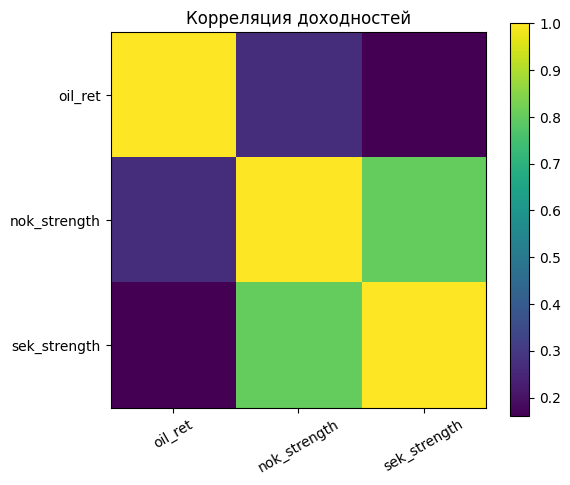

In [28]:
plt.figure(figsize=(6, 5))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Корреляция доходностей")
plt.tight_layout()
plt.savefig(output_dir / "correlation_matrix.png", dpi=200)
plt.show()


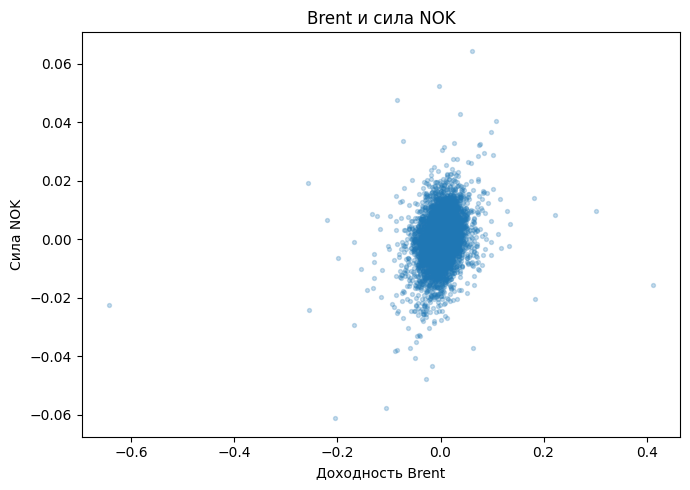

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(returns["oil_ret"], returns["nok_strength"], alpha=0.25, s=8)
plt.title("Brent и сила NOK")
plt.xlabel("Доходность Brent")
plt.ylabel("Сила NOK")
plt.tight_layout()
plt.savefig(output_dir / "oil_nok_scatter.png", dpi=200)
plt.show()


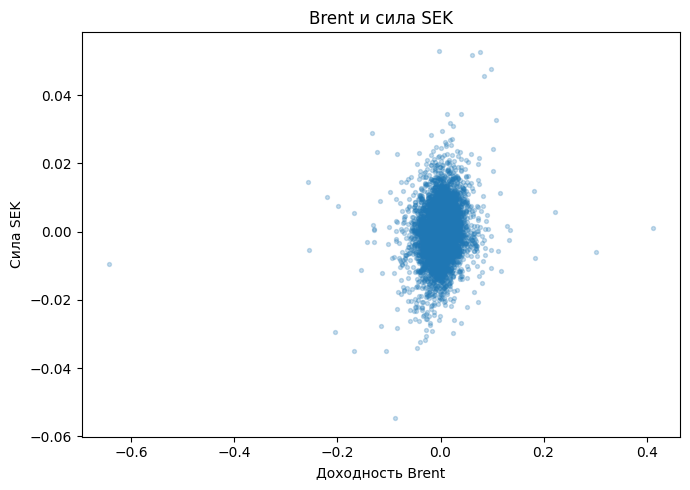

In [30]:
plt.figure(figsize=(7, 5))
plt.scatter(returns["oil_ret"], returns["sek_strength"], alpha=0.25, s=8)
plt.title("Brent и сила SEK")
plt.xlabel("Доходность Brent")
plt.ylabel("Сила SEK")
plt.tight_layout()
plt.savefig(output_dir / "oil_sek_scatter.png", dpi=200)
plt.show()


## 9. Базовая регрессионная модель

Оценивается модель:

$$r^{strength}_{FX,t}=\alpha+\beta r^{oil}_t+\varepsilon_t$$

Коэффициент $\beta$ показывает чувствительность валюты к изменению цены нефти.

Если $\beta>0$, рост цены нефти связан с укреплением валюты.


In [31]:
def fit_ols(data, y_col, x_cols, model_name):
  model_data = data[[y_col] + x_cols].dropna()
  y = model_data[y_col]
  x = sm.add_constant(model_data[x_cols])
  fit = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
  table = pd.DataFrame({
    "model": model_name,
    "variable": fit.params.index,
    "coef": fit.params.values,
    "std_err": fit.bse.values,
    "t_stat": fit.tvalues.values,
    "p_value": fit.pvalues.values,
    "r2": fit.rsquared,
    "nobs": int(fit.nobs)
  })
  return fit, table


nok_base_fit, nok_base_table = fit_ols(
  returns,
  "nok_strength",
  ["oil_ret"],
  "NOK base"
)

sek_base_fit, sek_base_table = fit_ols(
  returns,
  "sek_strength",
  ["oil_ret"],
  "SEK base"
)

base_models = pd.concat([nok_base_table, sek_base_table], ignore_index=True)

base_models.to_csv(output_dir / "base_regression_results.csv", index=False)

base_models


,model,variable,coef,std_err,t_stat,p_value,r2,nobs
0,NOK base,const,-0.000040,0.000089,-0.453696,6.500474e-01,0.072612,6522
1,NOK base,oil_ret,0.078094,0.010546,7.405112,1.310394e-13,0.072612,6522
2,SEK base,const,-0.000025,0.000086,-0.289208,7.724226e-01,0.025449,6522
3,SEK base,oil_ret,0.043991,0.007503,5.863280,4.538123e-09,0.025449,6522


In [32]:
print(nok_base_fit.summary())


                            OLS Regression Results                            
Dep. Variable:           nok_strength   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     54.84
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.48e-13
Time:                        11:02:13   Log-Likelihood:                 22697.
No. Observations:                6522   AIC:                        -4.539e+04
Df Residuals:                    6520   BIC:                        -4.538e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.022e-05   8.86e-05     -0.454      0.6

In [33]:
print(sek_base_fit.summary())


                            OLS Regression Results                            
Dep. Variable:           sek_strength   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     34.38
Date:                Wed, 20 May 2026   Prob (F-statistic):           4.76e-09
Time:                        11:02:13   Log-Likelihood:                 22859.
No. Observations:                6522   AIC:                        -4.571e+04
Df Residuals:                    6520   BIC:                        -4.570e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -2.5e-05   8.64e-05     -0.289      0.7

## 10. Модель с лагами нефти

Проверяется, реагирует ли валюта только в тот же день или с задержкой.


In [34]:
lagged = returns.copy()

for lag in range(1, 6):
  lagged[f"oil_ret_lag_{lag}"] = lagged["oil_ret"].shift(lag)

lag_cols = ["oil_ret"] + [f"oil_ret_lag_{lag}" for lag in range(1, 6)]

nok_lag_fit, nok_lag_table = fit_ols(
  lagged,
  "nok_strength",
  lag_cols,
  "NOK lagged"
)

sek_lag_fit, sek_lag_table = fit_ols(
  lagged,
  "sek_strength",
  lag_cols,
  "SEK lagged"
)

lag_models = pd.concat([nok_lag_table, sek_lag_table], ignore_index=True)

lag_models.to_csv(output_dir / "lagged_regression_results.csv", index=False)

lag_models


,model,variable,coef,std_err,t_stat,p_value,r2,nobs
0,NOK lagged,const,-0.000045,0.000089,-0.502484,6.153274e-01,0.074500,6517
1,NOK lagged,oil_ret,0.078130,0.010222,7.643121,2.120187e-14,0.074500,6517
2,NOK lagged,oil_ret_lag_1,0.011642,0.006844,1.700939,8.895445e-02,0.074500,6517
3,NOK lagged,oil_ret_lag_2,0.004588,0.005542,0.827965,4.076902e-01,0.074500,6517
4,NOK lagged,oil_ret_lag_3,0.002136,0.006066,0.352108,7.247571e-01,0.074500,6517
5,NOK lagged,oil_ret_lag_4,0.003645,0.004382,0.831909,4.054605e-01,0.074500,6517
6,NOK lagged,oil_ret_lag_5,-0.000130,0.004574,-0.028508,9.772573e-01,0.074500,6517
7,SEK lagged,const,-0.000026,0.000087,-0.302610,7.621867e-01,0.025974,6517
8,SEK lagged,oil_ret,0.044063,0.007379,5.971127,2.356201e-09,0.025974,6517
9,SEK lagged,oil_ret_lag_1,0.000540,0.004660,0.115858,9.077650e-01,0.025974,6517


## 11. Сравнение чувствительности NOK и SEK


In [35]:
beta_table = pd.DataFrame({
  "currency": ["NOK", "SEK"],
  "beta_oil": [
    nok_base_fit.params["oil_ret"],
    sek_base_fit.params["oil_ret"]
  ],
  "p_value": [
    nok_base_fit.pvalues["oil_ret"],
    sek_base_fit.pvalues["oil_ret"]
  ],
  "r2": [
    nok_base_fit.rsquared,
    sek_base_fit.rsquared
  ]
})

beta_table["abs_beta"] = beta_table["beta_oil"].abs()

beta_table.to_csv(output_dir / "beta_comparison.csv", index=False)

beta_table


,currency,beta_oil,p_value,r2,abs_beta
0,NOK,0.078094,1.310394e-13,0.072612,0.078094
1,SEK,0.043991,4.538123e-09,0.025449,0.043991


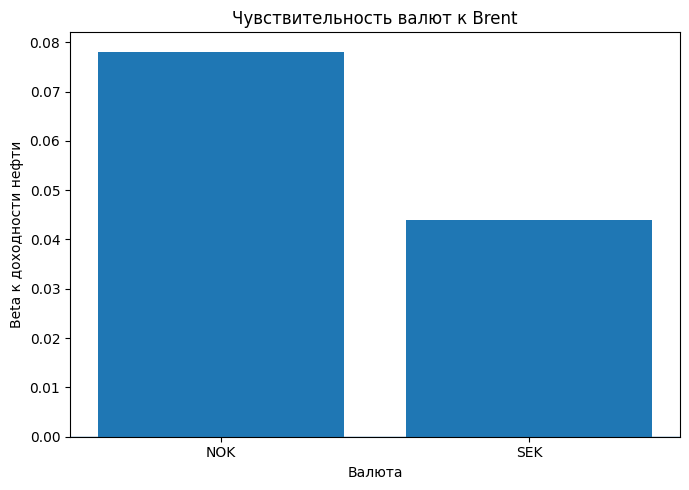

In [36]:
plt.figure(figsize=(7, 5))
plt.bar(beta_table["currency"], beta_table["beta_oil"])
plt.axhline(0, linewidth=1)
plt.title("Чувствительность валют к Brent")
plt.xlabel("Валюта")
plt.ylabel("Beta к доходности нефти")
plt.tight_layout()
plt.savefig(output_dir / "beta_comparison.png", dpi=200)
plt.show()


## 12. Rolling beta

Rolling beta показывает, стабильна ли связь во времени.


In [37]:
def rolling_beta(y, x, window):
  return y.rolling(window).cov(x) / x.rolling(window).var()


rolling = pd.DataFrame(index=returns.index)

rolling["nok_beta"] = rolling_beta(
  returns["nok_strength"],
  returns["oil_ret"],
  rolling_window
)

rolling["sek_beta"] = rolling_beta(
  returns["sek_strength"],
  returns["oil_ret"],
  rolling_window
)

rolling = rolling.dropna()

rolling.to_csv(output_dir / "rolling_beta.csv")

rolling.tail()


,nok_beta,sek_beta
observation_date,,
2026-05-05,0.013420,-0.058129
2026-05-06,0.014655,-0.056170
2026-05-07,0.014859,-0.056386
2026-05-08,0.015510,-0.056126
2026-05-11,0.015754,-0.056114


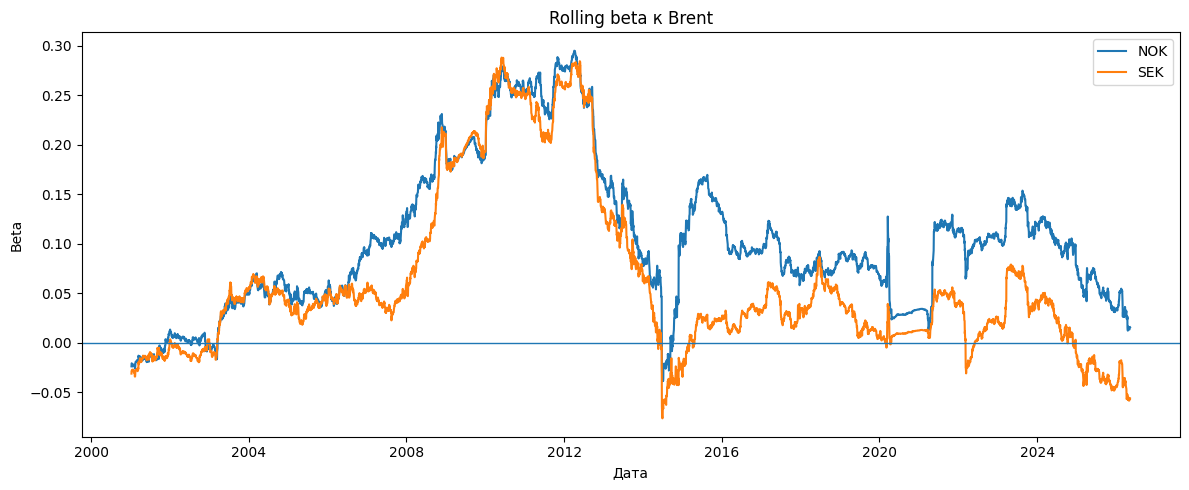

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(rolling.index, rolling["nok_beta"], label="NOK")
plt.plot(rolling.index, rolling["sek_beta"], label="SEK")
plt.axhline(0, linewidth=1)
plt.title("Rolling beta к Brent")
plt.xlabel("Дата")
plt.ylabel("Beta")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "rolling_beta.png", dpi=200)
plt.show()


## 13. Анализ по периодам

Отдельно проверяются спокойные и кризисные периоды.


In [39]:
periods = {
  "2000-2019": ("2000-01-01", "2019-12-31"),
  "2020-2021": ("2020-01-01", "2021-12-31"),
  "2022-2023": ("2022-01-01", "2023-12-31"),
  "2024-now": ("2024-01-01", None)
}


period_rows = []

for period_name, bounds in periods.items():
  left, right = bounds
  part = returns.loc[returns.index >= pd.to_datetime(left)]

  if right is not None:
    part = part.loc[part.index <= pd.to_datetime(right)]

  if len(part) < 50:
    continue

  nok_fit, _ = fit_ols(part, "nok_strength", ["oil_ret"], f"NOK {period_name}")
  sek_fit, _ = fit_ols(part, "sek_strength", ["oil_ret"], f"SEK {period_name}")

  period_rows.append({
    "period": period_name,
    "nobs": len(part),
    "nok_beta": nok_fit.params["oil_ret"],
    "nok_p_value": nok_fit.pvalues["oil_ret"],
    "nok_r2": nok_fit.rsquared,
    "sek_beta": sek_fit.params["oil_ret"],
    "sek_p_value": sek_fit.pvalues["oil_ret"],
    "sek_r2": sek_fit.rsquared
  })

period_table = pd.DataFrame(period_rows)

period_table.to_csv(output_dir / "period_regression_results.csv", index=False)

period_table


,period,nobs,nok_beta,nok_p_value,nok_r2,sek_beta,sek_p_value,sek_r2
0,2000-2019,4969,0.102343,3.657648e-49,0.092932,0.075768,1.531863e-22,0.052093
1,2020-2021,489,0.039921,2.716462e-02,0.054652,0.014389,1.063226e-01,0.016531
2,2022-2023,486,0.109415,1.369839e-08,0.097294,0.028880,2.234477e-01,0.008125
3,2024-now,578,0.031224,1.293009e-02,0.015101,-0.046366,6.432164e-04,0.033368


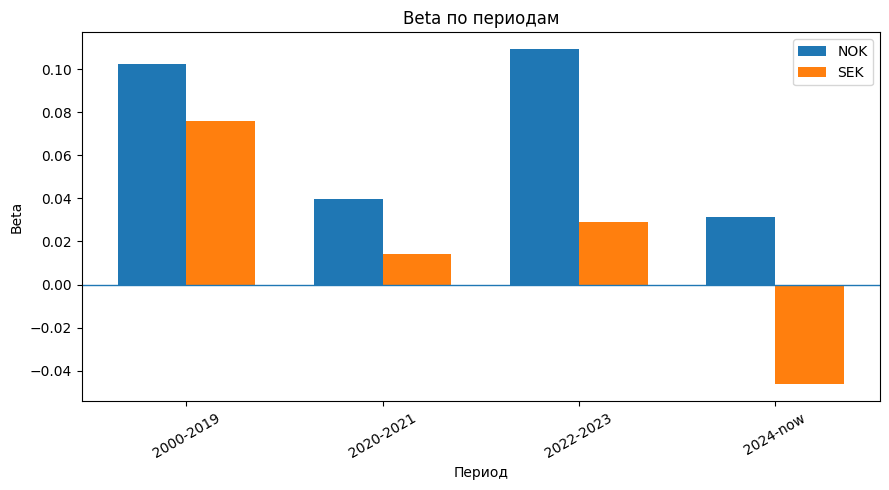

In [40]:
plt.figure(figsize=(9, 5))
x = np.arange(len(period_table))
width = 0.35

plt.bar(x - width / 2, period_table["nok_beta"], width, label="NOK")
plt.bar(x + width / 2, period_table["sek_beta"], width, label="SEK")
plt.axhline(0, linewidth=1)
plt.xticks(x, period_table["period"], rotation=30)
plt.title("Beta по периодам")
plt.xlabel("Период")
plt.ylabel("Beta")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "period_betas.png", dpi=200)
plt.show()


## 14. VaR и Expected Shortfall

Для валютного риска используется показатель потерь.

Для USD/NOK и USD/SEK рост курса означает ослабление NOK или SEK к доллару. Поэтому потери по валюте задаются как положительная доходность USD/NOK или USD/SEK.


In [41]:
def var_es(losses, level):
  value_at_risk = losses.quantile(level)
  expected_shortfall = losses[losses >= value_at_risk].mean()
  return value_at_risk, expected_shortfall


risk_rows = []

for currency, loss_col in [("NOK", "nok_loss"), ("SEK", "sek_loss")]:
  losses = returns[loss_col].dropna()

  for level in var_levels:
    value_at_risk, expected_shortfall = var_es(losses, level)
    risk_rows.append({
      "currency": currency,
      "level": level,
      "VaR": value_at_risk,
      "ES": expected_shortfall
    })

risk_table = pd.DataFrame(risk_rows)

risk_table.to_csv(output_dir / "historical_var_es.csv", index=False)

risk_table


,currency,level,VaR,ES
0,NOK,0.95,0.012362,0.017941
1,NOK,0.99,0.021314,0.027834
2,SEK,0.95,0.011621,0.016563
3,SEK,0.99,0.019606,0.024652


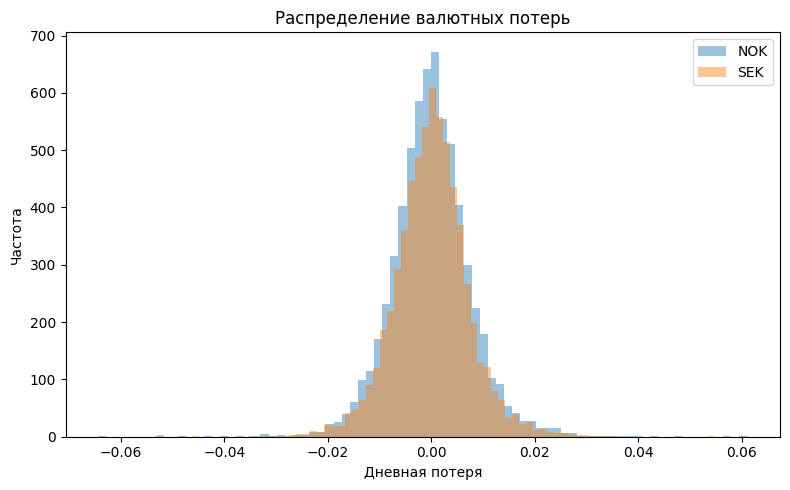

In [42]:
plt.figure(figsize=(8, 5))

for currency, loss_col in [("NOK", "nok_loss"), ("SEK", "sek_loss")]:
  plt.hist(returns[loss_col], bins=80, alpha=0.45, label=currency)

plt.title("Распределение валютных потерь")
plt.xlabel("Дневная потеря")
plt.ylabel("Частота")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "loss_distribution.png", dpi=200)
plt.show()


## 15. Backtesting исторического VaR

Проверяется, насколько часто фактические потери превышают VaR.


In [43]:
def backtest_var(losses, level, window):
  var_forecast = losses.rolling(window).quantile(level).shift(1)
  result = pd.DataFrame({
    "loss": losses,
    "var": var_forecast
  }).dropna()
  result["exception"] = result["loss"] > result["var"]
  return {
    "level": level,
    "window": window,
    "observations": len(result),
    "exceptions": int(result["exception"].sum()),
    "exception_rate": result["exception"].mean(),
    "expected_rate": 1 - level
  }


backtest_rows = []

for currency, loss_col in [("NOK", "nok_loss"), ("SEK", "sek_loss")]:
  for level in var_levels:
    row = backtest_var(returns[loss_col], level, rolling_window)
    row["currency"] = currency
    backtest_rows.append(row)

backtest_table = pd.DataFrame(backtest_rows)

backtest_table.to_csv(output_dir / "var_backtest.csv", index=False)

backtest_table


,level,window,observations,exceptions,exception_rate,expected_rate,currency
0,0.95,252,6270,336,0.053589,0.05,NOK
1,0.99,252,6270,92,0.014673,0.01,NOK
2,0.95,252,6270,353,0.056300,0.05,SEK
3,0.99,252,6270,95,0.015152,0.01,SEK


## 16. Сценарный анализ нефтяного шока

Нефтяной шок определяется как день, когда доходность Brent попадает в худшие 5% наблюдений.


In [44]:
oil_shock_threshold = returns["oil_ret"].quantile(0.05)
oil_shock_days = returns.loc[returns["oil_ret"] <= oil_shock_threshold]

scenario_table = pd.DataFrame({
  "metric": [
    "oil_shock_threshold",
    "number_of_shock_days",
    "mean_oil_return_on_shock_days",
    "mean_nok_loss_on_shock_days",
    "mean_sek_loss_on_shock_days",
    "var95_nok_loss_on_shock_days",
    "var95_sek_loss_on_shock_days"
  ],
  "value": [
    oil_shock_threshold,
    len(oil_shock_days),
    oil_shock_days["oil_ret"].mean(),
    oil_shock_days["nok_loss"].mean(),
    oil_shock_days["sek_loss"].mean(),
    oil_shock_days["nok_loss"].quantile(0.95),
    oil_shock_days["sek_loss"].quantile(0.95)
  ]
})

scenario_table.to_csv(output_dir / "oil_shock_scenario.csv", index=False)

scenario_table


,metric,value
0,oil_shock_threshold,-0.037354
1,number_of_shock_days,327.000000
2,mean_oil_return_on_shock_days,-0.059827
3,mean_nok_loss_on_shock_days,0.005461
4,mean_sek_loss_on_shock_days,0.002699
5,var95_nok_loss_on_shock_days,0.024382
6,var95_sek_loss_on_shock_days,0.021998


In [45]:
oil_drop = -0.10

predicted = pd.DataFrame({
  "currency": ["NOK", "SEK"],
  "oil_return_scenario": [oil_drop, oil_drop],
  "predicted_currency_strength": [
    nok_base_fit.params["const"] + nok_base_fit.params["oil_ret"] * oil_drop,
    sek_base_fit.params["const"] + sek_base_fit.params["oil_ret"] * oil_drop
  ]
})

predicted["predicted_usd_fx_change"] = -predicted["predicted_currency_strength"]

predicted.to_csv(output_dir / "predicted_10_percent_oil_drop.csv", index=False)

predicted


,currency,oil_return_scenario,predicted_currency_strength,predicted_usd_fx_change
0,NOK,-0.1,-0.007850,0.007850
1,SEK,-0.1,-0.004424,0.004424


## 17. Автоматическая интерпретация результатов


In [46]:
nok_beta = beta_table.loc[beta_table["currency"] == "NOK", "beta_oil"].iloc[0]
sek_beta = beta_table.loc[beta_table["currency"] == "SEK", "beta_oil"].iloc[0]

if abs(nok_beta) > abs(sek_beta):
  main_beta_result = "Связь Brent с NOK оказалась сильнее, чем связь Brent с SEK."
else:
  main_beta_result = "Связь Brent с SEK оказалась не слабее, чем связь Brent с NOK."

if nok_beta > 0:
  nok_direction = "Рост Brent связан с укреплением NOK."
else:
  nok_direction = "Рост Brent связан с ослаблением NOK."

if sek_beta > 0:
  sek_direction = "Рост Brent связан с укреплением SEK."
else:
  sek_direction = "Рост Brent связан с ослаблением SEK."

nok_var95 = risk_table.query("currency == 'NOK' and level == 0.95")["VaR"].iloc[0]
sek_var95 = risk_table.query("currency == 'SEK' and level == 0.95")["VaR"].iloc[0]

if nok_var95 > sek_var95:
  risk_result = "По историческому VaR валютный риск NOK выше, чем SEK."
else:
  risk_result = "По историческому VaR валютный риск SEK выше или сопоставим с NOK."

interpretation = pd.DataFrame({
  "block": [
    "Основная связь",
    "Направление для NOK",
    "Направление для SEK",
    "Риск"
  ],
  "interpretation": [
    main_beta_result,
    nok_direction,
    sek_direction,
    risk_result
  ]
})

interpretation.to_csv(output_dir / "automatic_interpretation.csv", index=False)

interpretation


,block,interpretation
0,Основная связь,"Связь Brent с NOK оказалась сильнее, чем связь..."
1,Направление для NOK,Рост Brent связан с укреплением NOK.
2,Направление для SEK,Рост Brent связан с укреплением SEK.
3,Риск,"По историческому VaR валютный риск NOK выше, ч..."


## 18. Финальный вывод для отчёта
В проекте была рассмотрена связь между доходностью нефти Brent и динамикой валют Норвегии и Швеции.
Для анализа использовались дневные данные по Brent, USD/NOK и USD/SEK за период с 2000 по 2026 год. После очистки данных были рассчитаны лог-доходности, а для валют использовался показатель силы валюты, так как рост USD/NOK и USD/SEK означает ослабление соответствующей валюты к доллару.

Корреляционный анализ показал, что связь Brent с норвежской кроной сильнее, чем со шведской кроной. Корреляция доходности Brent с силой NOK составила 0.269, а с силой SEK - 0.160.

Базовая регрессионная модель подтвердила основную гипотезу. Коэффициент чувствительности NOK к Brent равен 0.0781, а коэффициент чувствительности SEK равен 0.0440. Это означает, что при росте Brent на 10% норвежская крона в среднем укрепляется примерно на 0.78%, а шведская крона - примерно на 0.44%. Следовательно, чувствительность NOK к нефтяному фактору почти в 1.8 раза выше.

При этом R² в моделях невысокий: для NOK он равен 0.0726, а для SEK - 0.0254. Это означает, что нефть не объясняет всю динамику валютного курса, но является статистически значимым фактором, особенно для норвежской кроны.

После этого была проведена дополнительная эконометрическая проверка временных рядов. ADF и KPSS тесты показали, что логарифмы уровней Brent, USD/NOK и USD/SEK являются нестационарными, тогда как их лог-приросты можно считать стационарными. Это подтверждает корректность использования доходностей в базовой регрессионной модели и в дальнейшей VAR-модели.

Также была проверена возможность построения VECM. Для этого использовался тест коинтеграции Йохансена на логарифмах уровней Brent, USD/NOK и USD/SEK. Тест не выявил коинтеграцию на 5% уровне, поэтому построение VECM в данной спецификации не является обоснованным. В качестве расширенной модели более корректно использовать VAR на стационарных лог-приростах.

Выбор числа лагов для VAR показал, что AIC выбирает более длинную лаговую структуру, тогда как BIC и HQIC дают более короткую модель. Это говорит о том, что динамическая связь между нефтью и валютами может быть сложной, но результаты нужно интерпретировать осторожно, учитывая чувствительность модели к выбору лагов.

Дополнительно была проверена устойчивость результатов на дефлированных рядах. После дефлирования через CPI и PPI основной вывод сохранился: чувствительность NOK к Brent остается выше, чем чувствительность SEK. В CPI-спецификации коэффициент для NOK равен 0.0812, а для SEK - 0.0508. В PPI-спецификации коэффициент для NOK равен 0.0816, а для SEK - 0.0514. Это означает, что основной результат устойчив к альтернативной спецификации данных.

Rolling beta показала, что связь между нефтью и валютами не является постоянной во времени. В разные периоды чувствительность валют к Brent менялась, что говорит о влиянии рыночной конъюнктуры, макроэкономических факторов и глобального спроса на доллар.

В блоке риск-менеджмента были рассчитаны исторические VaR и Expected Shortfall. Исторический VaR 95% для NOK составил 1.236%, а для SEK - 1.162%. Expected Shortfall 95% для NOK равен 1.794%, для SEK - 1.656%. Таким образом, валютный риск NOK оказался немного выше, чем риск SEK.

Сценарный анализ нефтяного шока также подтвердил различие между валютами. В дни, когда Brent попадал в худшие 5% наблюдений, средняя потеря по NOK составляла 0.546%, а по SEK - 0.270%. Это показывает, что в периоды резкого падения нефти норвежская крона сильнее подвержена валютным потерям.

Общий вывод проекта состоит в том, что цена нефти Brent является статистически значимым фактором для динамики норвежской кроны. Для шведской кроны связь тоже присутствует, но она слабее и менее устойчива. Проверка стационарности, тест Йохансена, выбор лагов и дефлированные спецификации усиливают основной результат: нефтяной фактор особенно важно учитывать при управлении валютным риском активов, связанных с Норвегией и NOK.

### Основные файлы:
- `base_regression_results.csv`
- `beta_comparison.csv`
- `rolling_beta.png`
- `period_regression_results.csv`
- `historical_var_es.csv`
- `var_backtest.csv`
- `oil_shock_scenario.csv`
- `automatic_interpretation.csv`
